# Olist Brazilian E-Commerce — Python Data Analysis

Only the four main libraries are used: **Pandas, NumPy, Matplotlib and Seaborn**.

## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load All Datasets

All datasets are loaded once.

In [15]:
customers=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_customers_dataset.xlsx")
geolocation=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_geolocation_dataset.xlsx")
order_items=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_order_items_dataset.xlsx")
payment=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_order_payments_dataset.xlsx")
reviews=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_order_reviews_dataset.xlsx")
orders=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_orders_dataset.xlsx")
products=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_products_dataset.xlsx")
sellers=pd.read_excel(r"C:\Users\ADMIN\Desktop\olist_dataset_analysis\data\cleaned_excel_files\olist_sellers_dataset.xlsx")

In [16]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payment": payment,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers
}

summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})
summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,customers,99441,5,0,0
1,geolocation,738305,5,0,0
2,order_items,112650,7,0,0
3,payment,103886,5,0,0
4,reviews,99224,7,145932,0
5,orders,99441,8,4908,0
6,products,32951,9,1838,0
7,sellers,3095,4,0,0


## 3. Pandas Cleaning & Preparation

In [17]:
# Standardize column names and remove exact duplicate rows
for name, df in datasets.items():
    df.columns = df.columns.str.strip()
    datasets[name] = df.drop_duplicates().copy()

# Restore dataframe references after cleaning
customers = datasets["customers"]
geolocation = datasets["geolocation"]
order_items = datasets["order_items"]
payment = datasets["payment"]
reviews = datasets["reviews"]
orders = datasets["orders"]
products = datasets["products"]
sellers = datasets["sellers"]

# Convert Olist date columns once
date_columns = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Convert review creation/answer dates if present
for col in ["review_creation_date", "review_answer_timestamp"]:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

# Basic cleaning of numeric fields
for col in ["price", "freight_value"]:
    order_items[col] = pd.to_numeric(order_items[col], errors="coerce")

for col in ["payment_value", "payment_installments"]:
    payment[col] = pd.to_numeric(payment[col], errors="coerce")

# Final cleaning check
cleaning_summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows After Cleaning": [df.shape[0] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})
cleaning_summary

,Dataset,Rows After Cleaning,Missing Values,Duplicate Rows
0,customers,99441,0,0
1,geolocation,738305,0,0
2,order_items,112650,0,0
3,payment,103886,0,0
4,reviews,99224,145932,0
5,orders,99441,4908,0
6,products,32951,1838,0
7,sellers,3095,0,0


## 4. Order & Sales Analysis

In [18]:
# Create one row per order from order_items to avoid double-counting item-level data
order_value = order_items.groupby("order_id", as_index=False).agg(
    revenue=("price", "sum"),
    freight=("freight_value", "sum"),
    items=("order_item_id", "count")
)

order_level = orders.merge(order_value, on="order_id", how="left")
order_level[["revenue", "freight", "items"]] = order_level[["revenue", "freight", "items"]].fillna(0)
order_level["total_order_value"] = order_level["revenue"] + order_level["freight"]

order_level["month_year"] = order_level["order_purchase_timestamp"].dt.to_period("M").astype(str)
order_level["delivery_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_purchase_timestamp"]
).dt.total_seconds() / 86400
order_level["delivery_delay_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
order_level["late_delivery"] = (order_level["delivery_delay_days"] > 0).astype(int)

print("Total orders:", order_level["order_id"].nunique())
print("Total revenue:", round(order_level["revenue"].sum(), 2))
print("Average order value:", round(order_level["total_order_value"].mean(), 2))

Total orders: 99441
Total revenue: 13591643.7
Average order value: 159.33


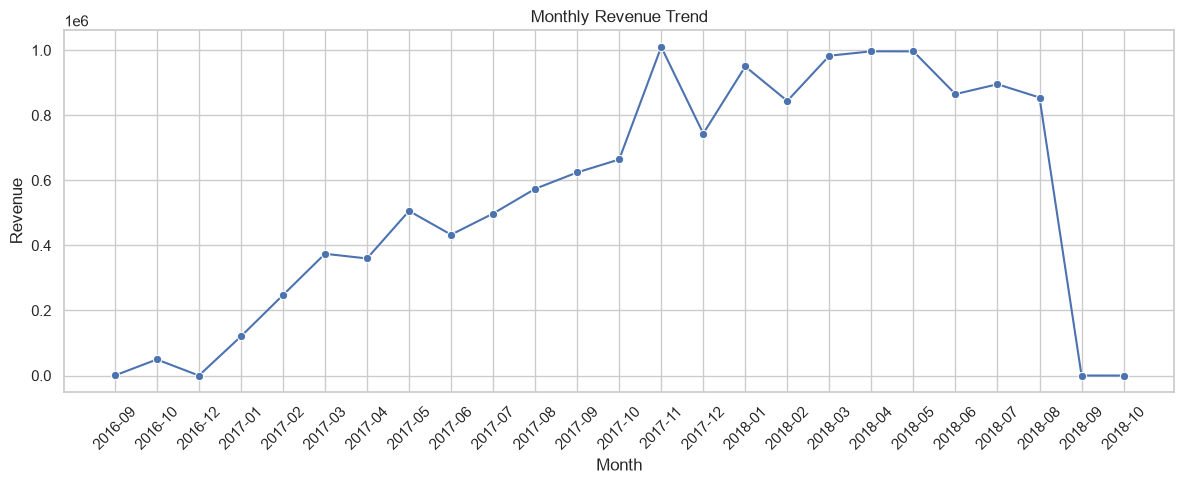

In [19]:
# Monthly revenue trend
monthly_sales = order_level.groupby("month_year", as_index=False).agg(
    revenue=("revenue", "sum"),
    orders=("order_id", "nunique")
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="month_year", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

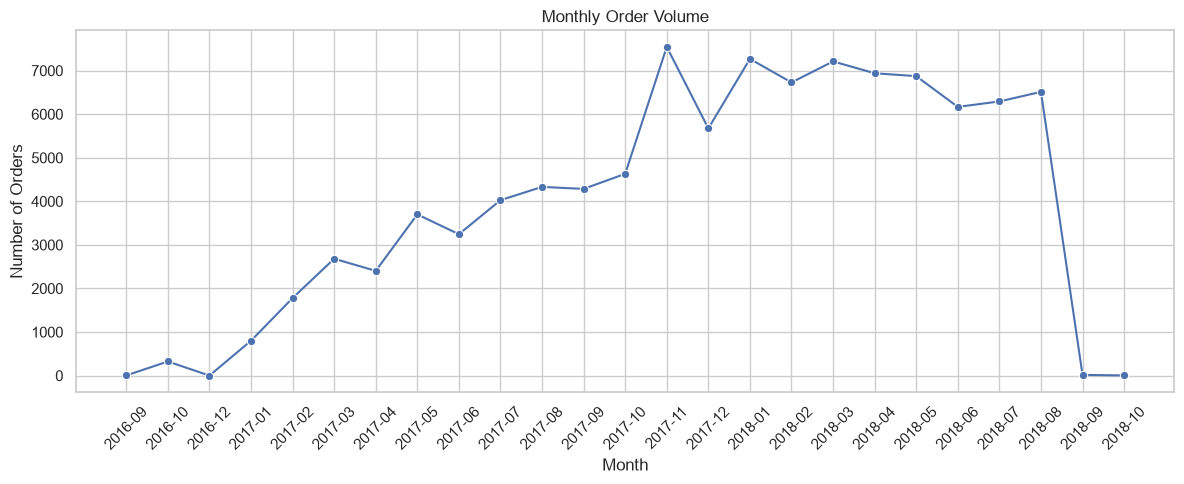

In [20]:
# Monthly order volume
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="month_year", y="orders", marker="o")
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Order Status Distribution

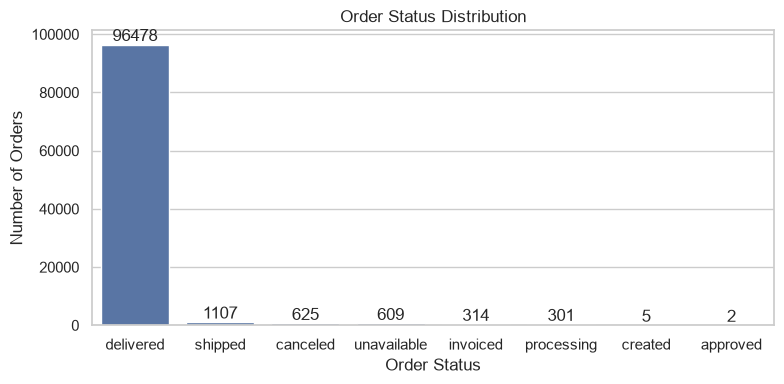

In [21]:
status_counts = orders["order_status"].value_counts()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 5. Payment Analysis

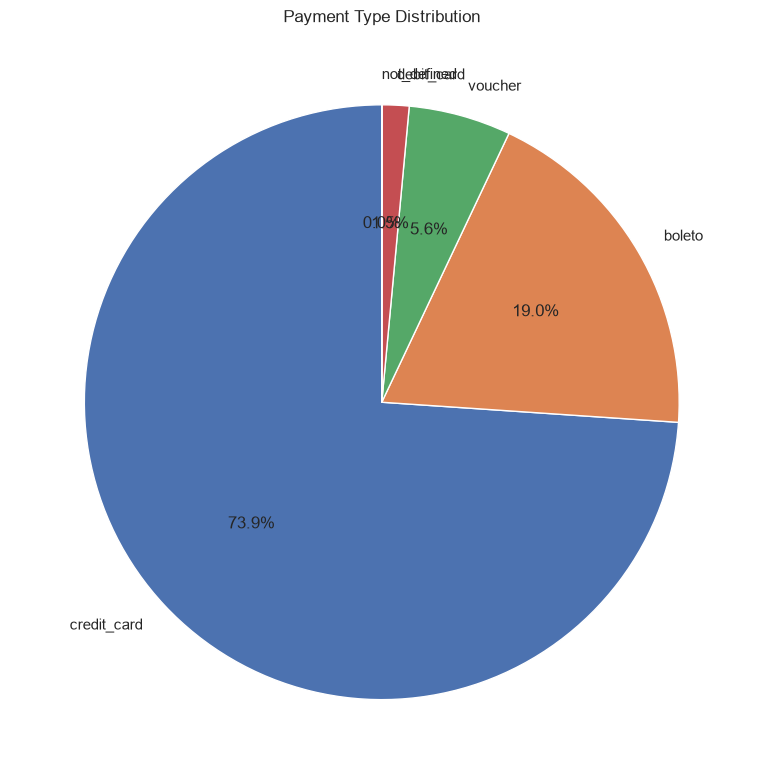

,payment_type,transactions,payment_value
1,credit_card,76795,12542084.19
0,boleto,19784,2869361.27
4,voucher,5775,379436.87
2,debit_card,1529,217989.79
3,not_defined,3,0.00


In [22]:
payment_counts = payment["payment_type"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Payment Type Distribution")
plt.tight_layout()
plt.show()

payment_summary = payment.groupby("payment_type", as_index=False).agg(
    transactions=("order_id", "count"),
    payment_value=("payment_value", "sum")).sort_values("payment_value", ascending=False)
payment_summary

## 6. Customer Analysis

In [23]:
customer_orders = order_level.groupby("customer_id", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    total_spending=("total_order_value", "sum")
)
customer_orders["customer_type"] = np.where(
    customer_orders["total_orders"] > 1, "Repeat Customer", "One-time Customer"
)
customer_orders["average_order_value"] = (
    customer_orders["total_spending"] / customer_orders["total_orders"]
)

customer_type_counts = customer_orders["customer_type"].value_counts()
customer_type_counts

customer_type
One-time Customer    99441
Name: count, dtype: int64

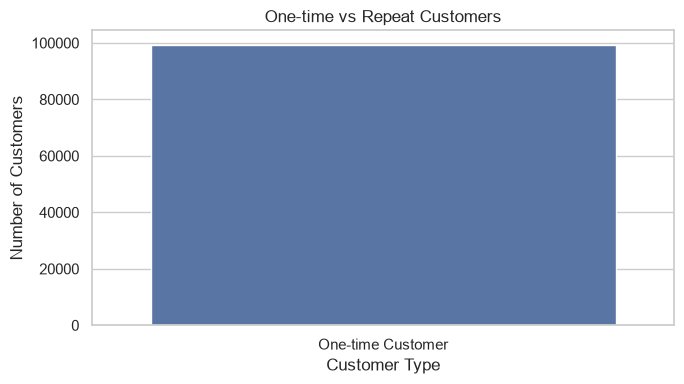

In [24]:
plt.figure(figsize=(7, 4))
sns.barplot(x=customer_type_counts.index, y=customer_type_counts.values)
plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 7. RFM Customer Analysis

In [26]:
# RFM is calculated on delivered orders only
delivered = order_level[order_level["order_status"] == "delivered"].copy()
delivered = delivered.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")

reference_date = delivered["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm = delivered.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("total_order_value", "sum")).reset_index()

rfm["R_score"] = pd.qcut(rfm["Recency"].rank(method="first"), 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_score"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

rfm["segment"] = np.select(
    [rfm["RFM_score"] >= 13, rfm["RFM_score"] >= 10, rfm["RFM_score"] >= 7],
    ["High Value", "Regular", "Needs Attention"],
    default="Low Value"
)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,9,Needs Attention
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,6,Low Value
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,4,Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,4,Low Value
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,7,Needs Attention


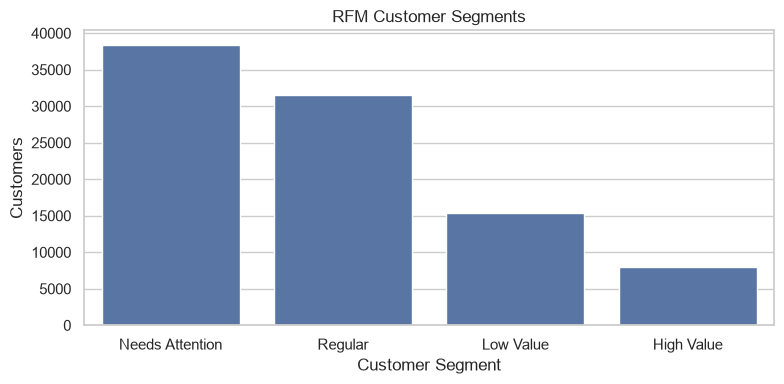

In [27]:
plt.figure(figsize=(8, 4))
sns.countplot(data=rfm, x="segment", order=rfm["segment"].value_counts().index)
plt.title("RFM Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## 8. Product & Category Analysis

In [30]:
product_sales = order_items.groupby("product_id", as_index=False).agg(
    units_sold=("order_item_id", "count"),
    revenue=("price", "sum"),
    freight=("freight_value", "sum"))

product_analysis = product_sales.merge(
    products[["product_id", "product_category_name", "product_weight_g"]],
    on="product_id", how="left"
)

category_analysis = product_analysis.groupby("product_category_name", dropna=False, as_index=False).agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    freight=("freight", "sum"),
    average_weight_g=("product_weight_g", "mean"))
category_analysis["freight_percentage"] = (
    category_analysis["freight"] / category_analysis["revenue"] * 100
)
category_analysis = category_analysis.sort_values("revenue", ascending=False)
category_analysis.head(10)

,product_category_name,units_sold,revenue,freight,average_weight_g,freight_percentage
11,beleza_saude,9670,1258681.34,182566.73,1434.793781,14.504603
66,relogios_presentes,5991,1205005.68,100535.93,509.287434,8.343191
13,cama_mesa_banho,11115,1036988.68,204693.04,2456.405084,19.739178
32,esporte_lazer,8641,988048.97,168607.51,2024.670736,17.064692
44,informatica_acessorios,7827,911954.32,147318.08,898.377669,16.154107
54,moveis_decoracao,8334,729762.49,172749.30,3008.266842,23.671989
26,cool_stuff,3796,635290.85,84039.10,2566.579214,13.228445
73,utilidades_domesticas,6964,632248.66,146149.11,3020.793576,23.115764
8,automotivo,4235,592720.11,92664.21,2654.650526,15.633721
40,ferramentas_jardim,4347,485256.46,98962.75,3103.776892,20.393907


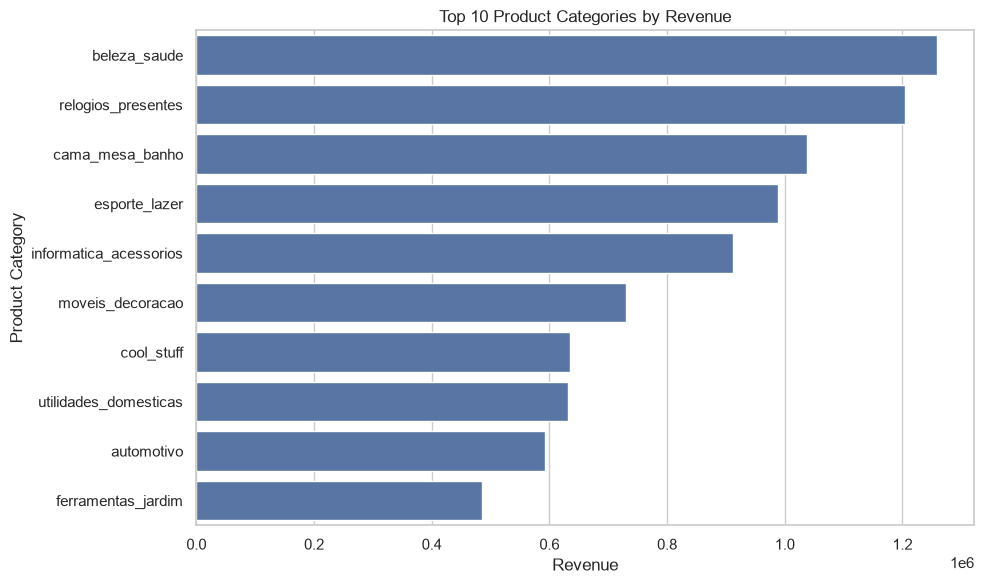

In [31]:
top_categories = category_analysis.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, y="product_category_name", x="revenue")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

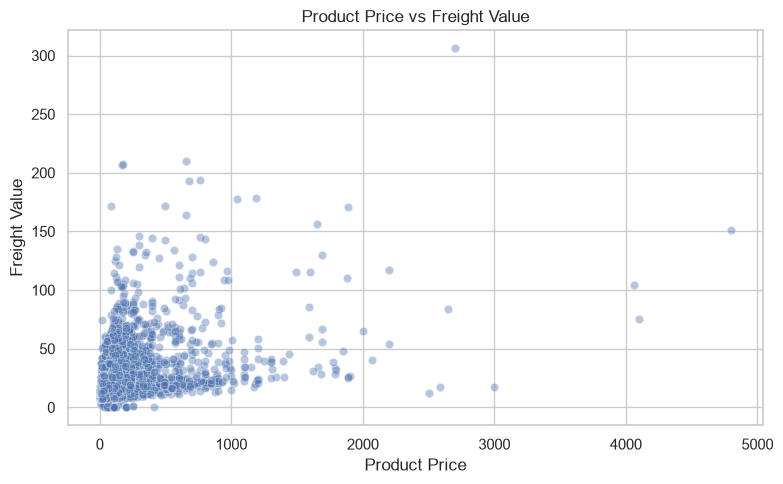

In [32]:
sample_items = order_items[["price", "freight_value"]].dropna().sample(
    min(10000, len(order_items)), random_state=42
)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_items, x="price", y="freight_value", alpha=0.4)
plt.title("Product Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.tight_layout()
plt.show()

## 9. Seller Analysis

In [34]:
seller_sales = order_items.groupby("seller_id", as_index=False).agg(
    units_sold=("order_item_id", "count"),
    revenue=("price", "sum"),
    freight=("freight_value", "sum"),
    orders=("order_id", "nunique"))

# Use distinct seller-order pairs so an order with multiple items is not counted repeatedly
seller_order = order_items[["order_id", "seller_id"]].drop_duplicates()
seller_delivery = seller_order.merge(
    order_level[["order_id", "delivery_days", "late_delivery"]],
    on="order_id", how="left"
).groupby("seller_id", as_index=False).agg(
    average_delivery_days=("delivery_days", "mean"),
    late_delivery_percentage=("late_delivery", "mean"))
seller_delivery["late_delivery_percentage"] *= 100

seller_analysis = seller_sales.merge(seller_delivery, on="seller_id", how="left")
seller_analysis.sort_values("revenue", ascending=False).head(10)

,seller_id,units_sold,revenue,freight,orders,average_delivery_days,late_delivery_percentage
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63,20168.07,1132,15.062424,11.484099
1013,53243585a1d6dc2643021fd1853d8905,410,222776.05,13080.63,358,13.432183,4.189944
881,4a3ca9315b744ce9f8e9374361493884,1987,200472.92,35067.04,1806,14.486045,10.797342
3024,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03,10042.70,585,13.354636,10.085470
1535,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89,51612.55,982,22.338338,9.979633
1560,7e93a43ef30c4f03f38b393420bc753a,340,176431.87,6322.18,336,11.314593,5.357143
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57,24955.75,1314,11.186555,7.610350
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53,20902.85,1160,11.200218,5.862069
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55,33892.14,915,12.391190,10.054645
1824,955fee9216a65b617aa5c0531780ce60,1499,135171.70,25430.98,1287,10.769857,7.614608


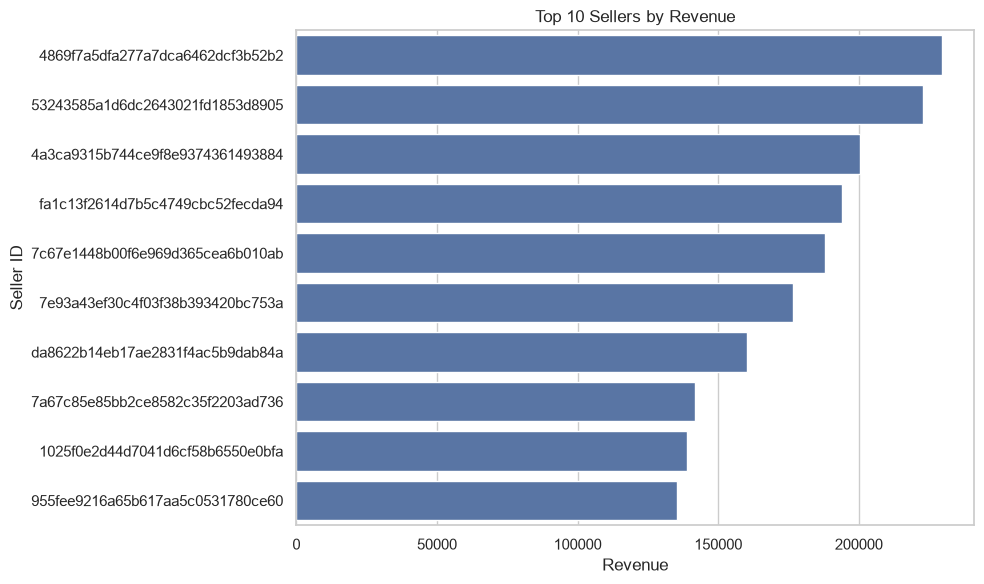

In [35]:
top_sellers = seller_analysis.sort_values("revenue", ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_sellers, y="seller_id", x="revenue")
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

## 10. Delivery Analysis

In [36]:
delivery_data = order_level[order_level["order_status"] == "delivered"].dropna(subset=["delivery_days"])

print("Average delivery time:", round(delivery_data["delivery_days"].mean(), 2), "days")
print("Median delivery time:", round(delivery_data["delivery_days"].median(), 2), "days")
print("Late delivery rate:", round(delivery_data["late_delivery"].mean() * 100, 2), "%")

Average delivery time: 12.56 days
Median delivery time: 10.22 days
Late delivery rate: 8.11 %


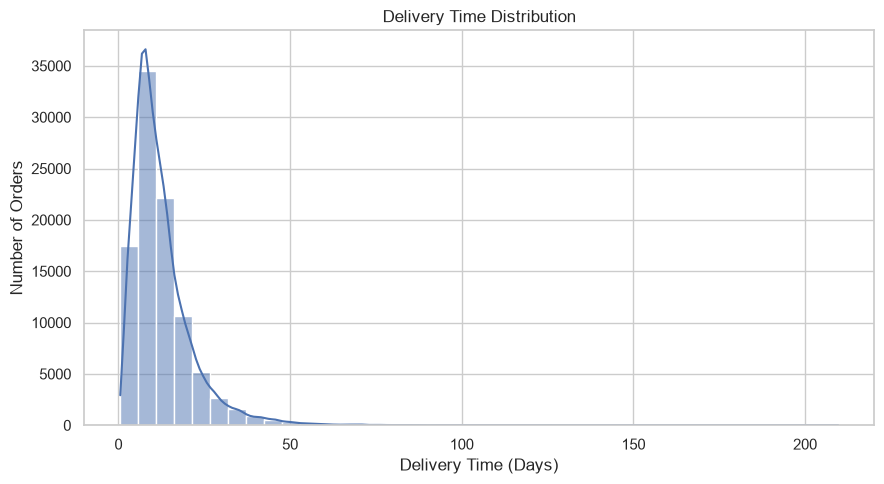

In [37]:
plt.figure(figsize=(9, 5))
sns.histplot(delivery_data["delivery_days"], bins=40, kde=True)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## 11. Delivery Time vs Review Score

In [39]:
# Reviews can contain multiple rows per order, so take one review score per order
review_order = reviews.groupby("order_id", as_index=False)["review_score"].mean()
delivery_reviews = delivery_data[["order_id", "delivery_days", "late_delivery"]].merge(
    review_order, on="order_id", how="inner")
delivery_reviews["delivery_status"] = np.where(
    delivery_reviews["late_delivery"] == 1, "Late", "On Time"
)

print(delivery_reviews.groupby("delivery_status")["review_score"].mean().round(2))

delivery_status
Late       2.57
On Time    4.29
Name: review_score, dtype: float64


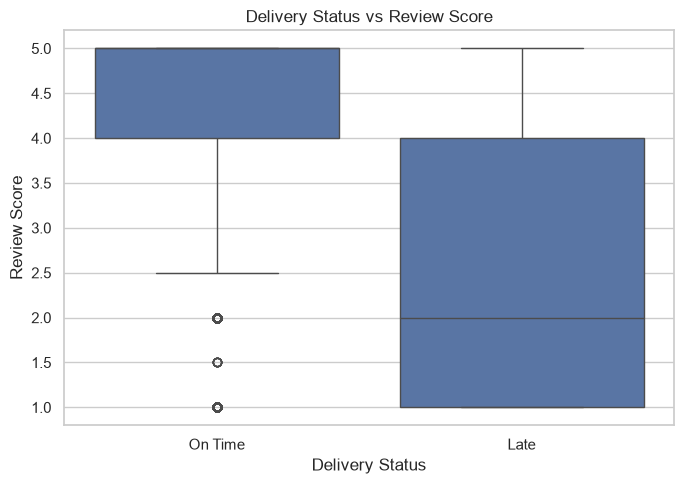

In [40]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=delivery_reviews, x="delivery_status", y="review_score")
plt.title("Delivery Status vs Review Score")
plt.xlabel("Delivery Status")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

## 12. Correlation Analysis

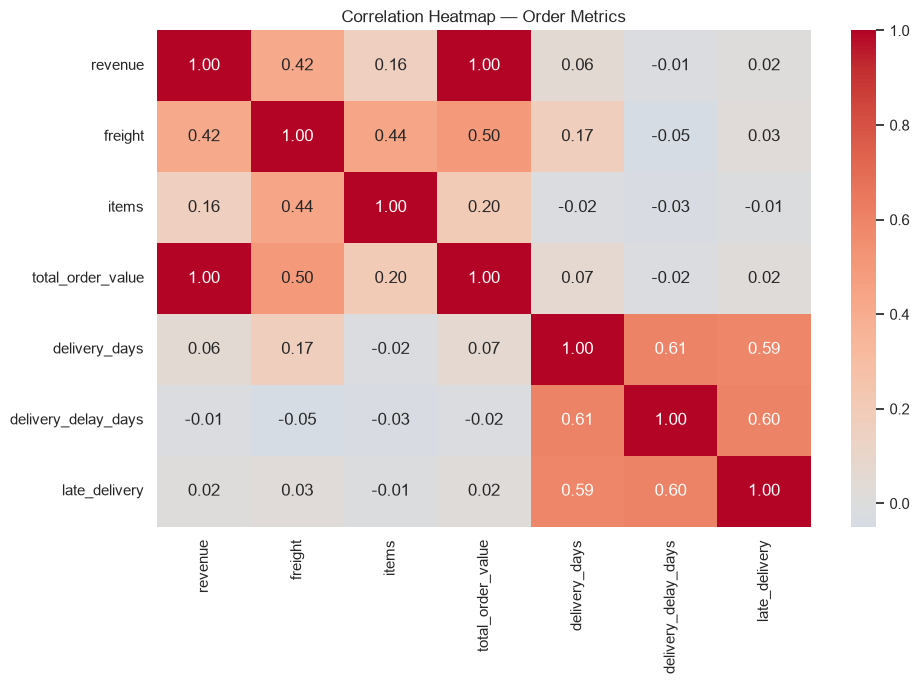

In [41]:
correlation_columns = [
    "revenue", "freight", "items", "total_order_value",
    "delivery_days", "delivery_delay_days", "late_delivery"
]
correlation_matrix = order_level[correlation_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Order Metrics")
plt.tight_layout()
plt.show()

## 13. Statistical Summary

In [42]:
statistical_summary = order_level[[
    "revenue", "freight", "items", "total_order_value",
    "delivery_days", "delivery_delay_days"
]].describe().T
statistical_summary

,count,mean,std,min,25%,50%,75%,max
revenue,99441.0,136.680481,210.172081,0.000000,45.000000,85.000000,149.900000,13440.000000
freight,99441.0,22.645685,21.659564,0.000000,13.720000,17.090000,23.920000,1794.960000
items,99441.0,1.132833,0.545666,0.000000,1.000000,1.000000,1.000000,21.000000
total_order_value,99441.0,159.326166,220.058804,0.000000,61.050000,104.560000,176.000000,13664.080000
delivery_days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
delivery_delay_days,96476.0,-11.179120,10.186113,-146.016123,-16.244384,-11.948941,-6.390000,188.975081


## 14. Key Business Findings

Used the outputs and charts above to document the main findings from the dataset, such as:
- revenue and order trends over time
- customer repeat-purchase behavior
- high-value customer segments from RFM
- top product categories and sellers
- delivery performance and late-delivery rate
- relationship between delivery performance and review scores
- relationships between order value, freight, items and delivery metrics from the correlation heatmap.